# Bitcoin-Treasury — is MicroStrategy just leveraged Bitcoin? 🟧
### A $100bn 'Bitcoin treasury' stock, taken apart in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Just_leveraged_Bitcoin%3F: Confirmed](https://img.shields.io/badge/Just_leveraged_Bitcoin%3F-Confirmed-8b949e?style=flat-square)

In August 2020 MicroStrategy (ticker **MSTR**) stopped being a sleepy software company and started buying Bitcoin — billions of dollars of it. The stock went vertical, and a story took hold: *MSTR is the smart way to own Bitcoin — leverage on the way up, plus a premium for the clever wrapper around the coins.* This notebook asks the only two questions that matter: **is MSTR more than just leveraged Bitcoin — and does paying the premium actually leave you better off than holding the coin?**

> 📓 **This is the plain-language layer.** Want the regressions, the bootstrap confidence intervals and the capacity math? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

from bitcoin_treasury import data, strategy as st

TREASURY_START = "2020-08-11"

def load_treasury():
    """Real (btc, mstr) treasury-era frame if cached, else the synthetic tape."""
    frame, tape = data.load_real(n_days=1470, beta=1.8, alpha=0.0, premium_vol=0.30)
    if tape == "real":
        frame = frame.loc[frame.index >= TREASURY_START]
    return frame, tape

FRAME, TAPE = load_treasury()
BANNER = ("REAL tape (MSTR & BTC-USD, treasury era)" if TAPE == "real"
          else "SYNTHETIC tape (offline fallback — NOT real MSTR)")
print("tape in this run:", BANNER)
print("rows:", len(FRAME), " range:", FRAME.index[0].date(), "->", FRAME.index[-1].date())


tape in this run: REAL tape (MSTR & BTC-USD, treasury era)
rows: 1470  range: 2020-08-11 -> 2026-06-17


## The answer first 🎯

*(Headline numbers are the **real** MSTR/BTC tape, treasury era 2020-08 → 2026-06-17, from [docs/results.md](../docs/results.md). The executed cells below run on whichever tape this machine has — they banner which.)*

| Question | Plain answer |
|---|---|
| Is MSTR more than leveraged Bitcoin? | **No.** It moves like ~1.13× Bitcoin and half its daily wiggle *is* Bitcoin; the 'extra' return isn't real once you do the stats (*t* ≈ 1.1). |
| Did MSTR beat Bitcoin? | **Yes — but only because it's levered.** A plain levered-Bitcoin position would have done the same, with a *smaller* crash. |
| Does the premium pay? | **No.** It swings wildly and you can't time it; it's extra risk, not extra reward. |

> So MSTR is exactly what the bears say and the bulls half-admit: **leveraged Bitcoin in a costume.** A real bet, just not a *better* one.

## 1 · The claim

The bull case, stated at full strength:

> *MicroStrategy isn't just a Bitcoin proxy — it's **better** than holding Bitcoin. It gives you leverage without a margin call, the CEO is a genius capital allocator, and the stock trades at a premium to its coins for a reason. Buy MSTR, not BTC.*

There are really three promises bundled together: (1) **alpha** — skill beyond the leverage; (2) **MSTR beats BTC**; and (3) the **premium itself is valuable**. We'll test all three.

## 2 · So what?

MSTR is a **>$100bn** company whose entire thesis is *we hold Bitcoin, but better.* If that 'better' is real, it's free money: own the wrapper, beat the coin. If it's an illusion, then millions of investors are paying a fluctuating premium for **leverage they could rent more cheaply** — and taking a bigger drawdown for the privilege. This is the cleanest test on the desk of a single idea: **is leverage the same thing as skill?** (Spoiler from every other study here: no.)

## 3 · How would we even know?

Three simple experiments:

1. **Line MSTR up against Bitcoin** and ask: how much of MSTR's daily move is just Bitcoin's move, scaled up? Whatever's left is the 'skill.' We check whether that leftover is real or just noise.
2. **Build a fake MSTR** — a plain Bitcoin position dialled up to MSTR's leverage, paying a realistic borrowing cost. If real MSTR can't beat this copy-cat, the wrapper added nothing.
3. **Try to trade the premium** — buy MSTR only when it's 'cheap' versus its coins. If the premium is valuable, timing it should help.

**What would make us say 'mirage':** if the leftover return isn't statistically real, if the fake-MSTR keeps up with the real one, and if timing the premium does nothing. (It's all three.)

## 4 · The teardown — let's actually look

### First: how much of MSTR is just Bitcoin?

Every dot below is one day: Bitcoin's move across, MSTR's move up. If MSTR were *purely* leveraged Bitcoin, the dots would sit on a straight line through the origin. The slope is the leverage; the scatter around it is everything else.

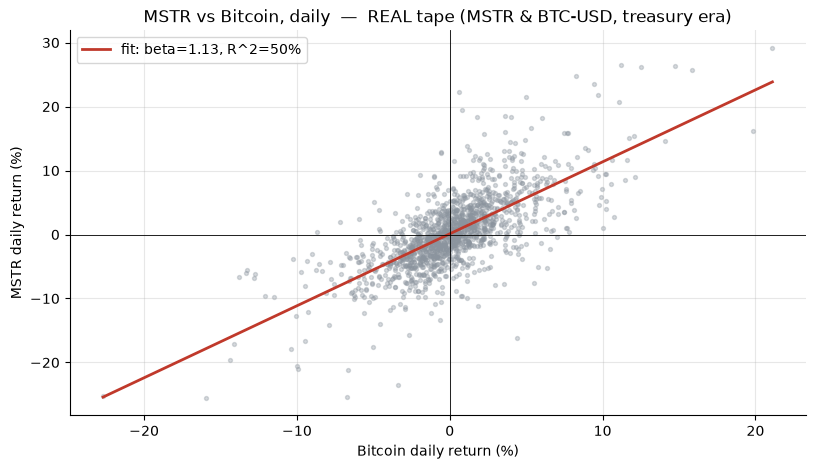

MSTR moves like 1.13x Bitcoin; 50% of its daily variance is just Bitcoin.


In [2]:
r_mstr = st.simple_returns(FRAME['mstr'])
r_btc  = st.simple_returns(FRAME['btc'])
common = r_mstr.index.intersection(r_btc.index)
dec = st.beta_decomposition(FRAME)

fig, ax = plt.subplots()
ax.scatter(r_btc.loc[common]*100, r_mstr.loc[common]*100, s=8, alpha=.35, color=GREY)
xs = np.linspace(r_btc.loc[common].min(), r_btc.loc[common].max(), 50)
ax.plot(xs*100, (dec['alpha_daily'] + dec['beta']*xs)*100, color=RED, lw=2,
        label=f"fit: beta={dec['beta']:.2f}, R^2={dec['r2']*100:.0f}%")
ax.axhline(0, color='k', lw=.6); ax.axvline(0, color='k', lw=.6)
ax.set_xlabel('Bitcoin daily return (%)'); ax.set_ylabel('MSTR daily return (%)')
ax.set_title(f'MSTR vs Bitcoin, daily  —  {BANNER}'); ax.legend()
plt.show()
print(f"MSTR moves like {dec['beta']:.2f}x Bitcoin; "
      f"{dec['r2']*100:.0f}% of its daily variance is just Bitcoin.")

On the **real tape** the slope is about **1.13× Bitcoin**, and **R² ≈ 50%** — half of MSTR's day-to-day life is literally Bitcoin moving. The leftover ('alpha') looks juicy on paper (**+39%/yr**) but its *t*-stat is only **1.08** — below the bar where we'd call it real. That's the first promise gone.

> 🔬 **For the quants:** the intercept's Newey-West *t* is the inference-bar number; the companion notebook shows it with its standard error and a block-bootstrap CI.

### Second: did MSTR really beat Bitcoin — or just lever it?

Let's grow $1 in MSTR, in Bitcoin, and in a **fake MSTR** (Bitcoin dialled up to MSTR's leverage, paying borrow). If the wrapper is magic, real MSTR pulls ahead of the fake.

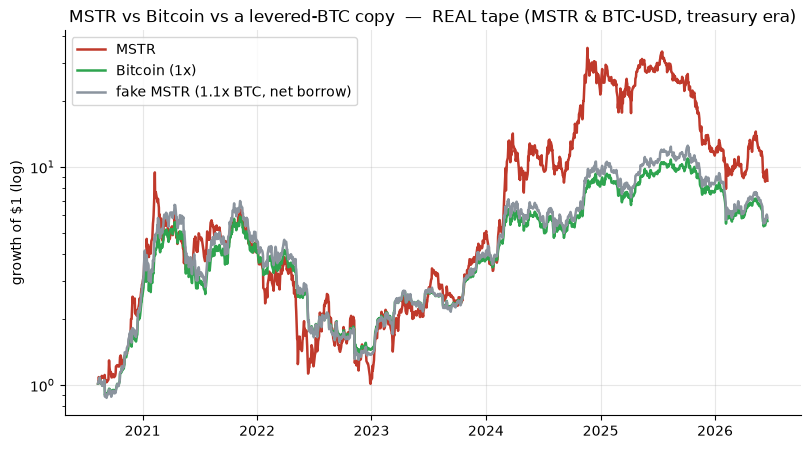

MSTR-minus-fake daily edge: +11.0 bps  (HAC t = +1.10)


In [3]:
race = st.race_mstr_vs_proxy(FRAME, rf_daily=0.03/365,
                             financing_bps_per_day=0.08/365*1e4)
lev = race['leverage']
proxy = st.levered_btc_proxy(FRAME, lev, 0.08/365*1e4)
idx = r_mstr.index.intersection(r_btc.index).intersection(proxy.index)
curves = {
    'MSTR': (1+r_mstr.loc[idx]).cumprod(),
    'Bitcoin (1x)': (1+r_btc.loc[idx]).cumprod(),
    f'fake MSTR ({lev:.1f}x BTC, net borrow)': (1+proxy.loc[idx]).cumprod(),
}
fig, ax = plt.subplots()
for (name, c), col in zip(curves.items(), [RED, GREEN, GREY]):
    ax.plot(c.index, c.values, label=name, color=col, lw=1.8)
ax.set_yscale('log'); ax.set_ylabel('growth of $1 (log)')
ax.set_title(f'MSTR vs Bitcoin vs a levered-BTC copy  —  {BANNER}'); ax.legend()
plt.show()
print(f"MSTR-minus-fake daily edge: {race['diff_mean_bps']:+.1f} bps  "
      f"(HAC t = {race['diff_t']:+.2f})")

On the real tape MSTR did beat *plain* Bitcoin (**+71%/yr vs +54%/yr**) — but the **fake MSTR did basically the same (+55%/yr)**, because the win was *leverage*, not skill. MSTR's edge over its own copy-cat is a statistically insignificant **+11 bps/day** (*t* = 1.1), and the real MSTR took a **worse crash (−89% vs −81%)**. You paid the premium and got *more* pain.

### Third: can you trade the premium?

MSTR's price swings far above and below the value of the coins it holds. If that premium is valuable, buying only when it's 'cheap' should beat just holding. Let's see the premium swing, then test the timing rule.

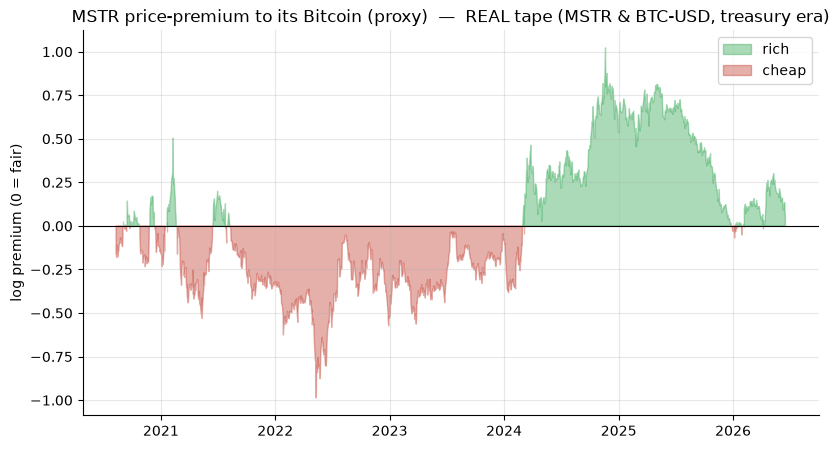

Buy-cheap timing vs always-hold: -9.3 bps/day (HAC t = -0.88); in market 50% of days


In [4]:
prem = st.nav_premium(FRAME)
tim = st.premium_timing(FRAME, cost_bps=5.0)
fig, ax = plt.subplots()
ax.fill_between(prem.index, prem.values, 0, where=prem.values>=0, color=GREEN, alpha=.4, label='rich')
ax.fill_between(prem.index, prem.values, 0, where=prem.values<0,  color=RED,   alpha=.4, label='cheap')
ax.axhline(0, color='k', lw=.8)
ax.set_title(f'MSTR price-premium to its Bitcoin (proxy)  —  {BANNER}')
ax.set_ylabel('log premium (0 = fair)'); ax.legend()
plt.show()
print(f"Buy-cheap timing vs always-hold: {tim['diff_mean_bps']:+.1f} bps/day "
      f"(HAC t = {tim['diff_t']:+.2f}); in market {tim['pct_in_market']*100:.0f}% of days")

The premium is enormous and mean-reverts — but **timing it earned nothing** (real tape: **-9 bps/day, *t* = -0.88** — actually *negative*). The premium is **risk you carry, not a coupon you collect**, and a cheap/dear rule sits out exactly the days the leverage compounds. Third promise gone.

## 5 · The verdict

- **Signal — None.** MSTR is ~1.1× Bitcoin with half its variance *being* Bitcoin; the leftover return isn't statistically real.
- **Tradability — Mirage.** The outperformance is leverage you can rent more cheaply, with a smaller drawdown; the premium can't be timed.
- **Just leveraged Bitcoin? — Confirmed.** Exactly that, costume included.

MSTR is a *real* bet on Bitcoin. It is not a *better* one.

## 6 · Could you actually trade it?

The 'trade' here is *prefer MSTR to Bitcoin* — and it fails not on commissions but on the comparison itself: a levered-BTC position (or a Bitcoin ETF with margin, or a 2× BTC ETF) gives you the same upside, **cheaper financing, and a shallower crash.** The only thing MSTR adds is a **volatile premium you pay at the door and can't sell back on demand** — the closed-end-fund trap (think GBTC's +100% premium in 2017 → −50% discount in 2022). If you *want* leverage on Bitcoin, buy leverage on Bitcoin.

## 7 · Going further 🚪

- **The convertible-bond engine.** MSTR's leverage comes from convertible debt; modelling that explicitly (vs our constant-beta proxy) is the natural next fork.
- **The copy-cats.** A wave of 'Bitcoin treasury' companies now exists — same test, fresh tickers, almost certainly the same answer.
- **mNAV done right.** Our premium is a *price* proxy; wiring in actual coin-count and share-count data would sharpen the premium-timing null.

Fork it, break it, PR it.